# Part II - Ford GoBike System Data Presentation

### by Vikash Kushwaha

# Investigation Overview

This presentation summarizes the key findings from the exploratory analysis of the Ford GoBike System dataset for February 2019. The objective is to communicate the most important insights regarding rider behavior, trip duration, and usage patterns through a concise set of visualizations.

## Executive Summary

The key findings presented in this notebook are:

- Most bike trips last between **5 and 20 minutes**.
- Subscribers account for the majority of rides.
- Bike usage peaks during weekday commuting hours.
- Customers consistently take longer trips than Subscribers.
- Customer trips tend to be longer during weekends, indicating recreational riding behavior.

# Dataset Overview and Executive Summary

The Ford GoBike System dataset contains information about individual bike-sharing trips made during February 2019 in the San Francisco Bay Area. Each trip record includes trip duration, start and end times, station information, rider demographics, and membership type.

The presentation focuses on the most important findings identified during the exploratory analysis. The selected visualizations demonstrate how trip duration varies across user groups and how temporal riding patterns reveal the primary use of the bike-sharing system.

In [11]:
# Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
import warnings
warnings.simplefilter("ignore")

%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [12]:
# Load the dataset

df = pd.read_csv("201902-fordgobike-tripdata.csv")

In [14]:
# Data preprocessing

df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

df['start_hour'] = df['start_time'].dt.hour
df['start_day'] = df['start_time'].dt.day_name()

df['age'] = 2019 - df['member_birth_year']

# Remove unrealistic ages
df = df[(df['age'] >= 18) & (df['age'] <= 80)]

# Log transformation
df['log_duration'] = np.log10(df['duration_sec'])

base_color = sns.color_palette()[0]

# Visualization 1: Distribution of Trip Duration

Trip duration is the primary variable of interest. Understanding its distribution provides insight into how riders typically use the Ford GoBike system.

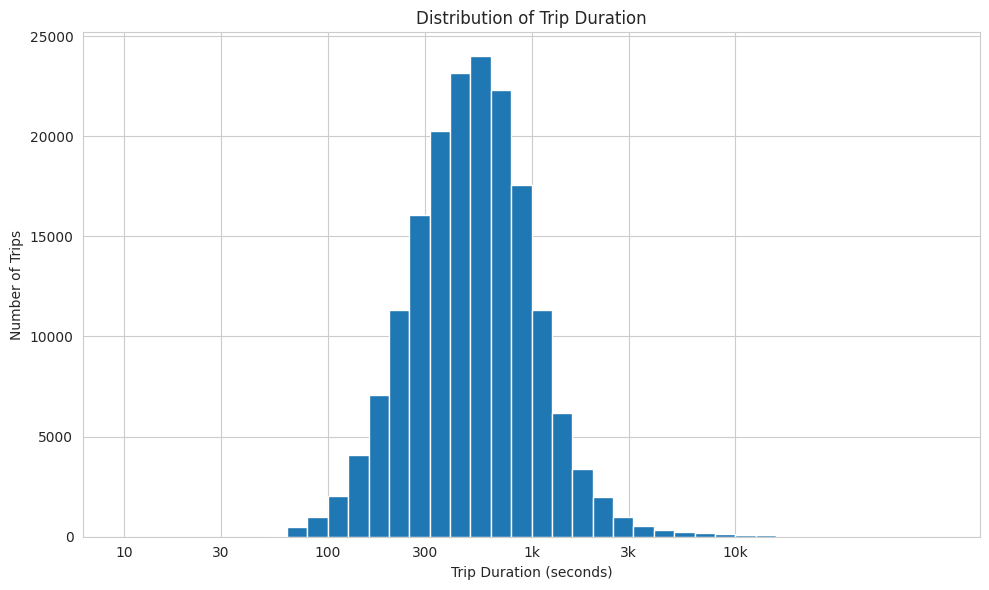

In [15]:
plt.figure(figsize=(10,6))

bins = 10 ** np.arange(1,5.1,0.1)

plt.hist(df['duration_sec'], bins=bins)

plt.xscale('log')

ticks = [10,30,100,300,1000,3000,10000]
labels = ['10','30','100','300','1k','3k','10k']

plt.xticks(ticks, labels)

plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.show()

### Observation

Most bike trips last between **5 and 20 minutes**, with relatively few long-duration rides. Applying a logarithmic scale provides a clearer view of the distribution by reducing the impact of extreme values.

# Visualization 2: Distribution of User Types

The distribution of user types illustrates how the bike-sharing system is primarily used and identifies the dominant rider group.

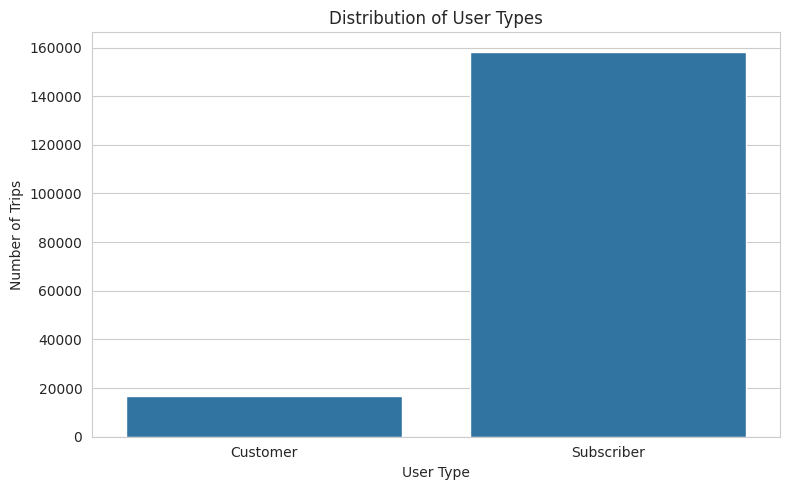

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='user_type',
    color=base_color
)

plt.title('Distribution of User Types')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.show()

### Observation

Subscribers account for the overwhelming majority of trips, indicating that the Ford GoBike system is primarily used by regular members. Customers represent a much smaller share of total rides, suggesting that they use the service more occasionally.

# Visualization 3: Bike Usage Throughout the Day

Trip frequency varies considerably throughout the day. Examining hourly ridership helps reveal commuting patterns and peak usage periods.

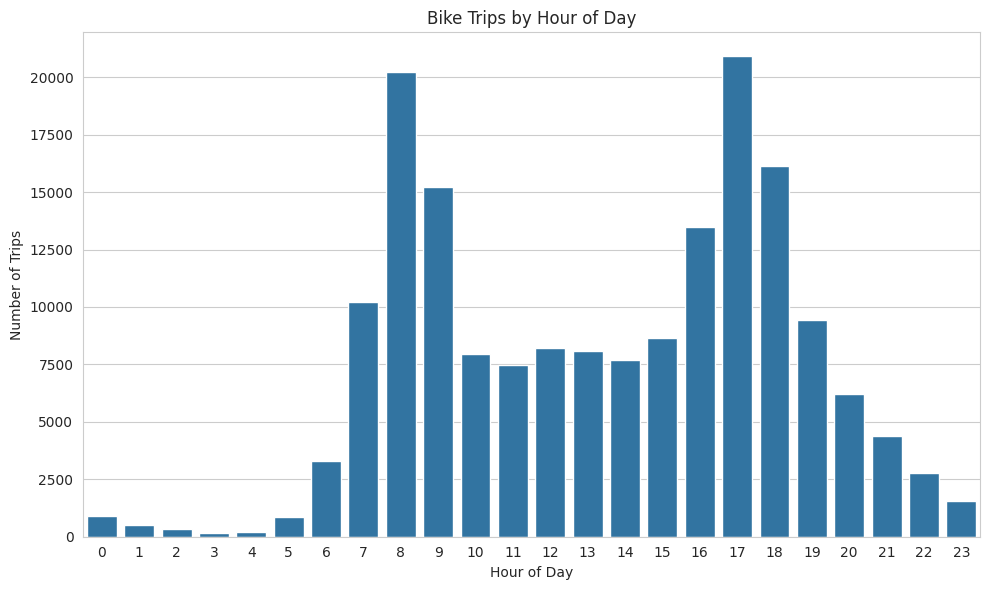

In [17]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='start_hour',
    color=base_color
)

plt.title('Bike Trips by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.show()

### Observation

Bike usage peaks during the morning and evening commuting hours, reflecting typical work-related travel patterns. Ridership is lowest during late-night and early-morning hours, reinforcing that the bike-sharing system is mainly used for daily transportation.

# Visualization 4: Trip Duration by User Type

Comparing trip duration across membership types highlights one of the strongest relationships identified during the exploratory analysis.

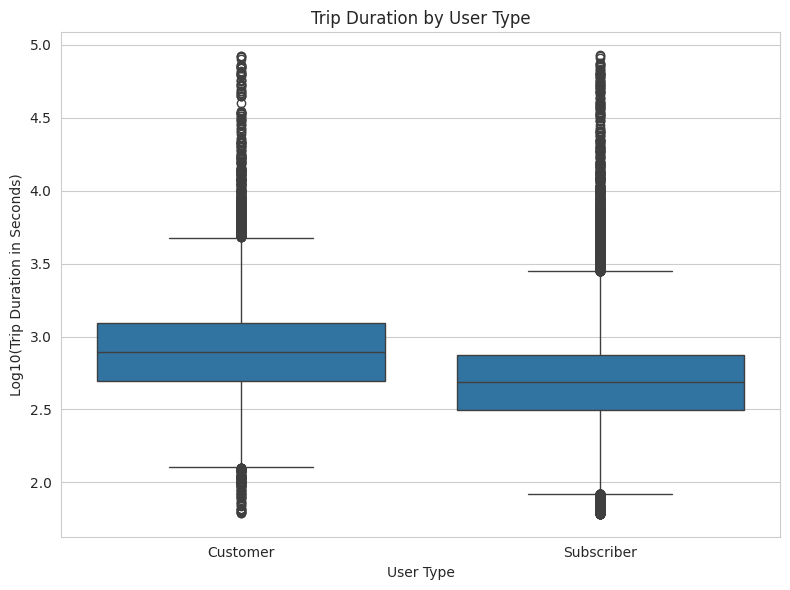

In [18]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='user_type',
    y='log_duration',
    color=base_color
)

plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Log10(Trip Duration in Seconds)')

plt.tight_layout()
plt.show()

### Observation

Customers generally take longer trips than Subscribers. While Subscriber ride durations remain relatively consistent, Customers exhibit greater variability and more long-duration rides. This suggests that Subscribers primarily use the system for commuting, whereas Customers are more likely to ride for leisure or recreational purposes.

# Visualization 5: Average Trip Duration by Day and User Type

Comparing average trip duration throughout the week provides additional insight into commuting and recreational riding behavior.

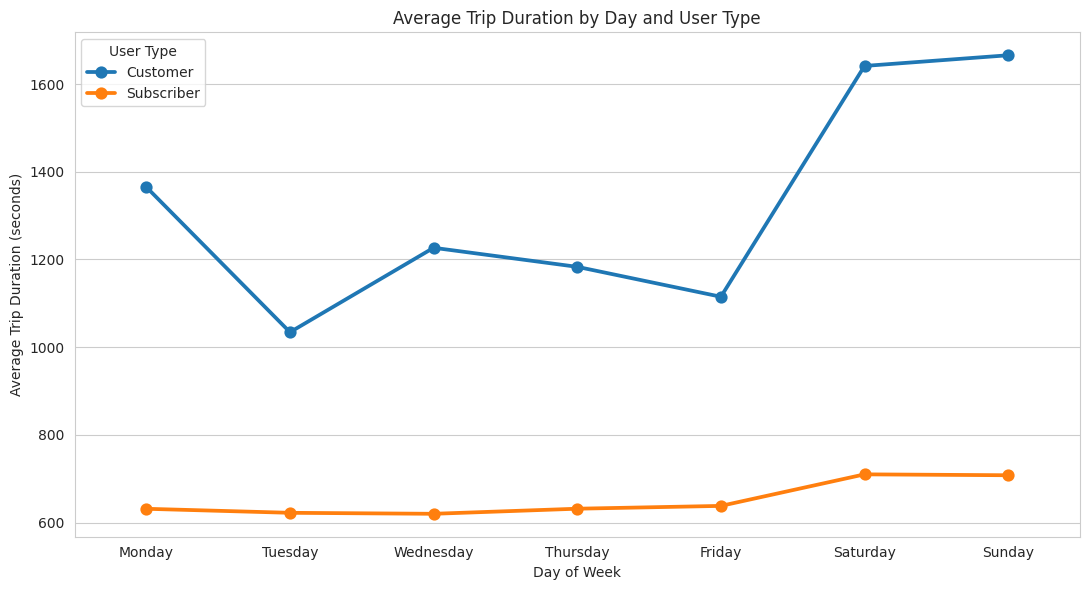

In [19]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

plt.figure(figsize=(11,6))

sns.pointplot(
    data=df,
    x='start_day',
    y='duration_sec',
    hue='user_type',
    order=day_order,
    errorbar=None
)

plt.title('Average Trip Duration by Day and User Type')
plt.xlabel('Day of Week')
plt.ylabel('Average Trip Duration (seconds)')

plt.legend(title='User Type')

plt.tight_layout()
plt.show()

### Observation

Subscribers maintain relatively consistent trip durations throughout the week, reflecting routine commuting behavior. In contrast, Customers generally take longer trips, particularly during weekends, suggesting that casual riders are more likely to use the bike-sharing service for recreational activities.

# Conclusion

The presentation highlights the most important findings from the exploratory analysis of the Ford GoBike System dataset.

### Summary of Findings

- Most bike trips last between **5 and 20 minutes**, indicating that the service is primarily used for short-distance travel.
- Subscribers account for the majority of trips, showing that the bike-sharing system mainly serves regular commuters.
- Ride activity peaks during the morning and evening hours, corresponding to typical weekday commuting times.
- Customers consistently take longer trips than Subscribers, suggesting different travel purposes between the two user groups.
- Customer trips tend to be longer during weekends, whereas Subscriber trip durations remain relatively stable throughout the week.

Overall, the analysis indicates that the Ford GoBike system is primarily a commuter-focused transportation service, while Customers use it more frequently for longer recreational trips.